In [1]:
import math
from tqdm.notebook import tqdm
import numpy as np
import pandas as pd
from scipy import stats
import pingouin as pg
import statsmodels.stats.power as smp
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import proportion_confint
import seaborn as sns
import matplotlib.pyplot as plt

**Кейс**
Давайте попробуем применить SPRT анализ в реальном АБ-тесте. Вы работаете аналитиков в команде искателей. Команда внедрила новую карточку объявлений авто. Основная цель вырастить конверсию в контакт в рамках одной сессии.
Аб-тест закончился и нам нужно проанализировать  результаты. У нас есть следующие данные:
cont_conv_A - конверсия по i-му пользователю в А группе
cont_conv_B - конверсия по j-му пользователю в B группе
данные в обоих колонках отсортированы по мере поступления в тест, т.е. более ранние строки это пользователи попавшие в тест раньше.
Менеджерам нужно дать ответ помогло ли изменение карточки авто повысить конверсию.

**Задания**
- 1. Проведем базовый z-тест на пропорцию. Тест двусторонний
- 2. Проведем SPRT анализ
- 3. Найти среднее время остановки SPRT анализа и сравнить с Fixed Horizon
- 4. Оценить мощность SPRT методики на наших данных

# SPRT для разницы долей / средних

In [2]:
# создадим функцию проводящую тест на проверку гипотезы о равенстве долей с попощью SPRT
def get_decision_list_sprt_binom(values_A, values_B, alpha = 0.05, beta = 0.2, mde = 0.1):
    ''' Функция проводящая SPRT анализ для пропорций (долей, конверсий)
    values_A - массив значенений коверсии (0, 1) в группе А
    values_B - массив значенений коверсии (0, 1) в группе B
    alpha - уровень статзначимости, который выдерживает SPRT
    beta - уровень ошибки второго рода, который выдерживает SPRT
    mde - абсолютная разница между долями в двух группах, MDE проверяемый в SPRT

    return
    - early_stop_index: индекс на котором SPRT остановился и принял решение.
        Если по результатам всех наблюдений SPRT не смог принять решение возвращается len(data)
    - inference: какая гипотеза была принята по результатам SPRT
    - h0_bound_list: массив границ для принятия решения H0. Длиной early_stop_index
    - h1_bound_list: массив границ для принятия решения H1. Длиной early_stop_index
    - S_list: массив рассчитываемых значений отражающих изменение динамики разницы долей. Длиной early_stop_index
    - cum_diff_list: массив кумулятивной нарастающей разницы между долями в двух группах. Длиной early_stop_index
    '''
    min_len = int(np.mean([len(values_A), len(values_B)]))
    A = math.log(beta/(1 - alpha))
    B = math.log((1 - beta)/alpha)
    p = (values_A.mean() + values_B.mean())/2 # генеральная доля по двум выборкам

    h0_bound_list = []
    h1_bound_list = []
    S_list = []
    cum_diff_list = []

    for i in range(100, min_len):
        p0_i = np.mean(values_A[0:i])
        p1_i = np.mean(values_B[0:i])

        #p = (p0_i + p1_i)/2

        disp = p * (1 - p)
        diff = p1_i - p0_i
        h0_bound = 2 * disp * A / mde
        h1_bound = 2 * disp *  B / mde

        S = (i + 1) * (diff - mde/2)

        h0_bound_list.append(h0_bound)
        h1_bound_list.append(h1_bound)
        S_list.append(S)
        cum_diff_list.append(diff)

        if S < h0_bound:
            return {'early_stop_index':i, 'inference':'Accept H0', 'h0_bound_list': h0_bound_list, 'h1_bound_list': h1_bound_list, 'S_list': S_list, 'cum_diff_list':cum_diff_list}
        if S > h1_bound:
            return {'early_stop_index':i, 'inference':'Accept H1', 'h0_bound_list': h0_bound_list, 'h1_bound_list': h1_bound_list, 'S_list': S_list, 'cum_diff_list':cum_diff_list}
    return {'early_stop_index':i, 'inference':'Continue', 'h0_bound_list': h0_bound_list, 'h1_bound_list': h1_bound_list, 'S_list': S_list, 'cum_diff_list':cum_diff_list}

# Загружаем данные

In [3]:
#Загружаем данные
df_data = pd.read_csv('4 SPRT_homework_1.csv')
df_data

,cont_conv_A,cont_conv_B
0,0,0
1,0,0
2,1,0
3,1,0
4,0,0
...,...,...
21253,0,0
21254,0,0
21255,0,0
21256,0,0


# Задание 1. Проведем базовый z-тест на пропорцию
Задание 3. Укажите p-value z-test

In [4]:
# conversions
conv_A = df_data['cont_conv_A'].sum()
conv_B = df_data['cont_conv_B'].sum()

# sample sizes
n_A = df_data['cont_conv_A'].count()
n_B = df_data['cont_conv_B'].count()

print(f"{conv_A=},{n_A=}, {conv_B=}, {n_B=}")
print(f"cr_A:{conv_A/n_A:2%}, cr_B:{conv_B/n_B:2%}, cr_diff:{conv_B/n_B-conv_A/n_A:2%}")

z_stat, p_value = proportions_ztest(
    count=[conv_B, conv_A],
    nobs=[n_B, n_A]
)

print(f"z-stat: {z_stat:.6f}")
print(f"p-value: {p_value:.6f}")

conv_A=np.int64(3627),n_A=np.int64(21258), conv_B=np.int64(3804), n_B=np.int64(21258)
cr_A:17.061812%, cr_B:17.894440%, cr_diff:0.832628%
z-stat: 2.260295
p-value: 0.023803


In [5]:
pg.ttest(
    x=df_data.cont_conv_B,
    y=df_data.cont_conv_A,
    paired=False,
    alternative='two-sided',
    correction='auto',
    confidence=0.95,
)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,2.260377,42514,two-sided,0.023803,"[0.0, 0.02]",0.021925,0.141,0.618062


# Задание 2. Проведем SPRT анализ
2. Укажите какая гипотеза верна по мнению SPRT?

In [6]:
h0 = df_data['cont_conv_A'].mean()
rel_mde = 0.05
h1 = h0 * (1 + rel_mde)
abs_mde = h0*rel_mde

inference_object = get_decision_list_sprt_binom(
    values_A=df_data.cont_conv_A,
    values_B=df_data.cont_conv_B,
    alpha=0.05,
    beta=0.2,
    mde=abs_mde)

In [7]:
print('2. Верна по мнению SPRT ->', inference_object['inference'])
print('На каком наблюдении сделан вывод:', inference_object['early_stop_index'])

2. Верна по мнению SPRT -> Accept H1
На каком наблюдении сделан вывод: 15314


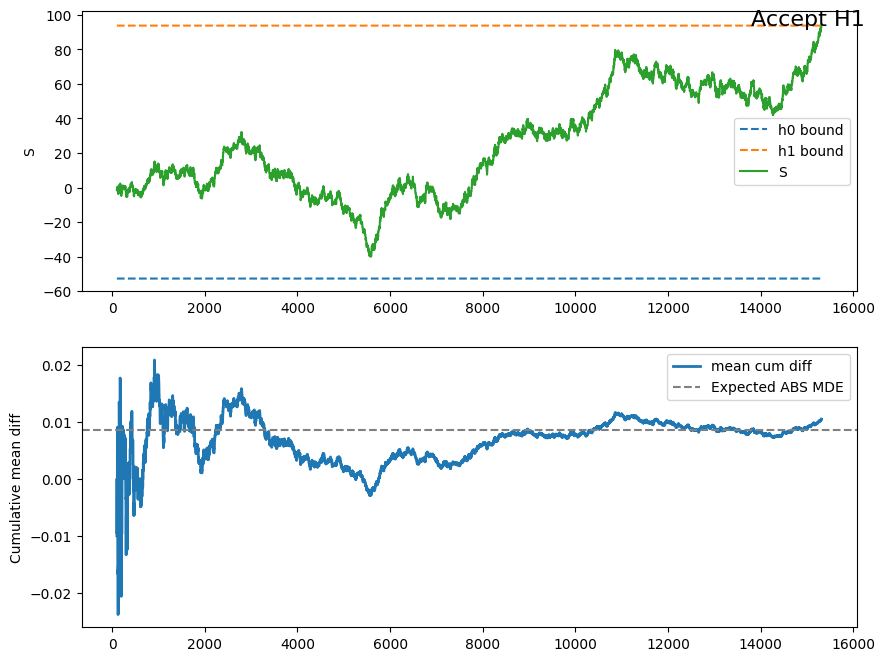

In [8]:
# plot SPRT decision
fig, axes = plt.subplots(2, figsize=(10,8))

sns.lineplot(ax=axes[0], x = np.arange(100, len(inference_object['h0_bound_list'])+100), y = inference_object['h0_bound_list'], ls = '--', label='h0 bound')
sns.lineplot(ax=axes[0], x = np.arange(100, len(inference_object['h1_bound_list'])+100), y = inference_object['h1_bound_list'], ls = '--', label='h1 bound')
sns.lineplot(ax=axes[0], x = np.arange(100, len(inference_object['S_list'])+100), y = inference_object['S_list'], label='S')
axes[0].set_ylabel(ylabel = "S")
axes[0].text(y = np.quantile(inference_object['h1_bound_list'], 0.75), x = len(inference_object['S_list']) * 0.9+100, s = inference_object['inference'], fontsize = 16)

axes[0].legend()

sns.lineplot(ax=axes[1], x = np.arange(100, len(inference_object['cum_diff_list'])+100), y = inference_object['cum_diff_list'], label='mean cum diff', linewidth=2)
axes[1].axhline(abs_mde, ls='--', color='gray', label = 'Expected ABS MDE')
axes[1].set_ylabel(ylabel = "Cumulative mean diff")
axes[1].legend()

# Задание 3. Определим в среднем на каком размере выборки мы бы останавливались имея на руках наши текущие данные (оценка размера выборки для SPRT)
3.1 Определим размер выборки нужный для fixed horizon
- **параметры дизайна**
- относительный MDE = 0.05
- альфа = 0.05
- бета = 0.2
- гипотеза - двусторонняя
- пропорция в выборке 50/50
- исторические данные - данные по конверсии в группе А

3.2 Определить среднее время остоновки для АА симуляций
- **Параметры симуляции**
- перед запуском указать np.random.seed(2)
- кол-во симуляций = 300
- для симуляции будем брать исторические данные многократно выборки кодом np.random.choice(data['cont_conv_A'], size = len(data['cont_conv_A'])). replace по умолчанию = True
- размер выборок в симуляции = sample size с предыдущего шага

3.3 Определить среднее время остоновки для АБ симуляций
- **Параметры симуляции те же**

3.4 Оцените мощность методики SPRT на имеющихся данных группы А и Б и относительном MDE = 0.05
- **Параметры симуляции те же**


In [9]:
alpha = 0.05
power = 0.80
mean = df_data.cont_conv_A.mean()
std = (mean * (1-mean))**0.5
mde_rel = 0.05
mde_abs = mean-mean*(1+0.05)
effect_size = mde_abs / std

smp.zt_ind_solve_power(
    effect_size=effect_size,
    nobs1=None,
    alpha=alpha,
    power=power,
    ratio=1.0,
    alternative='two-sided',
)

30522.913625769088

# Симуляция по оценке среднего времени остановки SPRT теста и оценки мощности теста

Размер выборки для Fixed Horizon: 31121
mde_absolute: 0.0085


  0%|          | 0/300 [00:00<?, ?it/s]

Доля случаев когда SPRT не успел принять решения до fixed horizon в АА варианте 0.043333333333333335
Доля случаев когда SPRT не успел принять решения до fixed horizon в AB варианте 0.043333333333333335
FP rate = 0.03333333333333333
FP 95% CI: (0.013020747761991785, 0.05364591890467488)
Power rate = 0.8366666666666667
Power 95% CI: (0.7948353909157111, 0.8784979424176222)


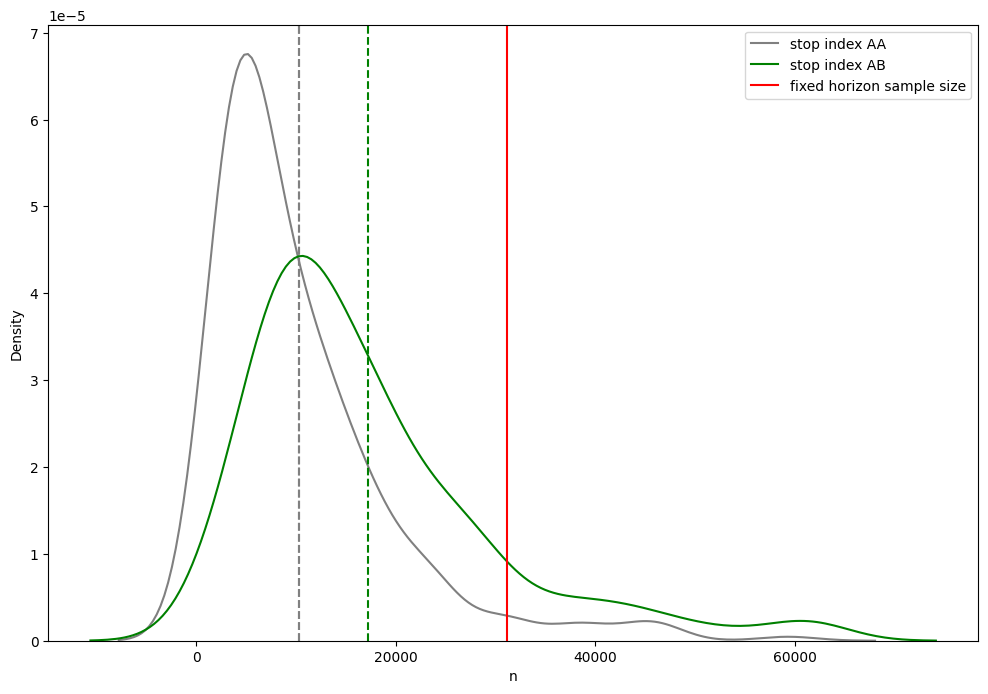

In [10]:
np.random.seed(2)

# определим размер выборки при Fixed Horizon для proportion тест 
h0 = df_data.cont_conv_A.mean()
rel_mde = 0.05
h1 = h0 * (1+ rel_mde)
alpha = 0.05
beta = 0.2
mde_abs = h1 - h0

cohen_d = 2*math.asin(np.sqrt(h0)) - 2*math.asin(np.sqrt(h0 * (1+rel_mde)))
n_obs = smp.zt_ind_solve_power(effect_size = cohen_d, 
                           alpha = alpha,
                           power = 1 - beta,
                           alternative='two-sided')
sample_size = round(n_obs)

print('Размер выборки для Fixed Horizon:', sample_size)
print('mde_absolute:', round(mde_abs, 4))

# проводим SPRT тест на полученных данных
inference_object = get_decision_list_sprt_binom(df_data.cont_conv_A, df_data.cont_conv_B, alpha = 0.05, beta = 0.2, mde = mde_abs)

inference_AA_list = []
inference_AB_list = []
stop_index_list_AA = []
stop_index_list_AB = []
diffs_list_AA = []
diffs_list_AB = []
sim_num = 300
for i in tqdm(range(sim_num)):
    # сгенерируем данные с конверсией с h0 и h1 конверсиями (с размером выборок с запасом)
    values_A1 = np.random.binomial(1, h0, sample_size*2) 
    values_A2 = np.random.binomial(1, h0, sample_size*2) 
    values_B = np.random.binomial(1, h1, sample_size*2) # выборка с добавленным эффектом
    
    inference_object_AA = get_decision_list_sprt_binom(values_A1, values_A2, alpha = 0.05, beta = 0.2, mde = mde_abs)
    inference_object_AB = get_decision_list_sprt_binom(values_A1, values_B, alpha = 0.05, beta = 0.2, mde = mde_abs)
    
    inference_AA = inference_object_AA['inference']
    inference_AB = inference_object_AB['inference']
    stop_index_AA = inference_object_AA['early_stop_index']
    stop_index_AB = inference_object_AB['early_stop_index']
    
    inference_AA_list.append(inference_AA)
    inference_AB_list.append(inference_AB)
    stop_index_list_AA.append(stop_index_AA)
    stop_index_list_AB.append(stop_index_AB)

FP = (np.array(inference_AA_list)=='Accept H1').sum() / sim_num
FP_CI = proportion_confint((np.array(inference_AA_list)=='Accept H1').sum() , sim_num, alpha=0.05)
power = (np.array(inference_AB_list)=='Accept H1').sum() / sim_num
power_CI = proportion_confint((np.array(inference_AB_list)=='Accept H1').sum() , sim_num, alpha=0.05)

print('Доля случаев когда SPRT не успел принять решения до fixed horizon в АА варианте', (np.array(stop_index_list_AA) > sample_size).mean())
print('Доля случаев когда SPRT не успел принять решения до fixed horizon в AB варианте',(np.array(stop_index_list_AA) > sample_size).mean())
print('FP rate =', FP)
print('FP 95% CI:', FP_CI)
print('Power rate =', power)
print('Power 95% CI:', power_CI)

# распределение времени остановки теста на конверсии с относительным MDE 5%
plt.figure(figsize = (12, 8))
sns.kdeplot(stop_index_list_AA, label = 'stop index AA', color = 'grey')
sns.kdeplot(stop_index_list_AB, label = 'stop index AB', color = 'green')
plt.axvline(x = np.mean(stop_index_list_AA), ls = '--', color = 'grey')
plt.xlabel('n')
plt.axvline(x = np.mean(stop_index_list_AB), ls = '--', color = 'green')
plt.axvline(x = sample_size, label = 'fixed horizon sample size', color = 'red')
plt.axvline(x = np.mean(stop_index_list_AA), ls = '--', color = 'grey')
plt.legend()

In [11]:
print('3.2. Среднее время остановки SPRT теста для АА-варианта =', round(np.mean(stop_index_list_AA)))
print('3.3. Среднее время остановки SPRT теста для АБ-варианта =', round(np.mean(stop_index_list_AB)))
print('3.4. Оценка мощности SPRT теста', power)

3.2. Среднее время остановки SPRT теста для АА-варианта = 10282
3.3. Среднее время остановки SPRT теста для АБ-варианта = 17252
3.4. Оценка мощности SPRT теста 0.8366666666666667
